# Adapter :: DreamBooth

-----
- Conda env : [cv_playgrounds](../../README.md#setup-a-conda-environment)
-----

- Ref: 
    - https://huggingface.co/docs/diffusers/v0.34.0/en/using-diffusers/dreambooth

## 0. Configure device

In [1]:
#@title
import torch

if torch.backends.mps.is_available():
    t_device = torch.device("mps")
    s_device = "mps"
    print(f"Current memory allocated on MPS: {torch.mps.current_allocated_memory()} bytes")
    print(f"Driver memory allocated on MPS: {torch.mps.driver_allocated_memory()} bytes")
    if torch.mps.driver_allocated_memory() - torch.mps.current_allocated_memory()< 1e4:
        print("Not enough mps memory, convert to cpu mode")
        t_device = torch.device("cpu")
        s_device = "cpu"
elif torch.cuda.is_available():
    t_device = torch.device("cuda")
    s_device = "cuda"
else:
    t_device = torch.device("cpu")
    s_device = "cpu"
print(t_device)

cuda


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/hyunjae/.cache/huggingface/hub/models--sd-dreambooth-library--herge-style/snapshots/33888ec1b1cb44429533e2ce41a9c927c94dff20/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /home/hyunjae/.cache/huggingface/hub/models--sd-dreambooth-library--herge-style/snapshots/33888ec1b1cb44429533e2ce41a9c927c94dff20/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /home/hyunjae/.cache/huggingface/hub/models--sd-dreambooth-library--herge-style/snapshots/33888ec1b1cb44429533e2ce41a9c927c94dff20/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /home/hyunjae/.cache/huggingface/hub/models--sd-dreambooth-library--herge-style/snapshots/33888ec1b1cb44429533e2ce41a9c927c94dff20/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


  0%|          | 0/50 [00:00<?, ?it/s]

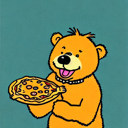

In [3]:
import torch
from diffusers import AutoPipelineForText2Image

pipeline = AutoPipelineForText2Image.from_pretrained(
    "sd-dreambooth-library/herge-style",
    torch_dtype=torch.float16
).to(t_device)
prompt = "A cute sks herge_style brown bear eating a slice of pizza, stunning color scheme, masterpiece, illustration"
pipeline(prompt).images[0].resize((128, 128))